# Notebook for testing out various models

### Models to Test : 
* ARIMA
* SARIMAX
* Prophet (formerly FBProphet)
* Random Forest & XGBoost
* LSTM
* GRU
* Transformer Models - BERT

In [1]:
# !pip install xgboost
# !pip install prophet
# !pip install torch
# !pip install lightgbm

## Libraries

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from prophet import Prophet
import torch

## Data

In [19]:
data = pd.read_csv("../data/MSFT.csv")
data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,S_3,S_9,S_18,...,RSI,Bollinger_Mid,Bollinger_Upper,Bollinger_Lower,Volume_Rolling_Mean,Volume_Change,Overall_Mean,Overall_Min,Overall_Max,Target
count,4624.000000,4624.000000,4624.000000,4624.000000,4.624000e+03,4624.000000,4624.0,4624.000000,4624.000000,4624.000000,...,4624.000000,4624.000000,4624.000000,4624.000000,4.624000e+03,4624.000000,4624.000000,4624.000000,4.624000e+03,4624.000000
mean,97.668328,98.619755,96.685851,97.700532,4.366770e+07,0.005433,0.0,97.609331,97.342446,96.949257,...,54.807419,96.861425,101.770685,91.952165,4.370419e+07,0.057563,97.452772,11.263444,4.425700e+02,97.791951
std,108.590577,109.614455,107.505575,108.623913,2.823090e+07,0.049509,0.0,108.500639,108.165280,107.683656,...,15.826388,107.574763,113.063351,102.185167,2.351244e+07,0.404716,0.000000,0.000000,5.684957e-14,108.736203
min,11.300617,11.612869,11.055273,11.263444,7.425600e+06,0.000000,0.0,11.325397,11.774779,12.167161,...,6.806087,12.228455,13.246611,10.709566,1.346000e+07,-0.808979,97.452772,11.263444,4.425700e+02,11.263444
25%,21.461364,21.622073,21.249248,21.470862,2.491638e+07,0.000000,0.0,21.437578,21.443549,21.446988,...,43.528815,21.458546,22.347419,20.431160,2.631419e+07,-0.178469,97.452772,11.263444,4.425700e+02,21.472810
50%,39.905392,40.232631,39.613691,39.945400,3.599870e+07,0.000000,0.0,39.904752,39.968142,39.665544,...,54.958045,39.629939,41.709249,37.576867,3.733673e+07,-0.013001,97.452772,11.263444,4.425700e+02,39.958326
75%,137.909078,138.920999,136.130181,137.602905,5.406152e+07,0.000000,0.0,137.679462,137.515890,135.500306,...,66.380397,135.332242,140.676410,128.992797,5.569644e+07,0.204908,97.452772,11.263444,4.425700e+02,137.877998
max,440.850006,443.399994,439.369995,441.579987,5.910522e+08,0.750000,0.0,438.439992,427.239997,426.472778,...,99.112239,425.885500,441.545030,415.076599,2.678342e+08,6.234345,97.452772,11.263444,4.425700e+02,442.570007


In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4624 entries, 0 to 4623
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 4624 non-null   object 
 1   Open                 4624 non-null   float64
 2   High                 4624 non-null   float64
 3   Low                  4624 non-null   float64
 4   Close                4624 non-null   float64
 5   Volume               4624 non-null   int64  
 6   Dividends            4624 non-null   float64
 7   Stock Splits         4624 non-null   float64
 8   S_3                  4624 non-null   float64
 9   S_9                  4624 non-null   float64
 10  S_18                 4624 non-null   float64
 11  lag_1                4624 non-null   float64
 12  lag_2                4624 non-null   float64
 13  lag_3                4624 non-null   float64
 14  Rolling_Mean         4624 non-null   float64
 15  Rolling_Min          4624 non-null   f

In [21]:
data

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,S_3,S_9,...,RSI,Bollinger_Mid,Bollinger_Upper,Bollinger_Lower,Volume_Rolling_Mean,Volume_Change,Overall_Mean,Overall_Min,Overall_Max,Target
0,2006-01-31 00:00:00-05:00,19.679359,20.010756,19.651156,19.848583,94841300,0.0,0.0,19.728718,19.029883,...,65.753580,19.034545,19.762916,18.306173,92388520.0,-0.088057,97.452772,11.263444,442.570007,19.771023
1,2006-02-01 00:00:00-05:00,19.714613,19.792175,19.573594,19.771023,68448800,0.0,0.0,19.787475,19.109795,...,60.807054,19.076851,19.873499,18.280204,94263860.0,-0.278281,97.452772,11.263444,442.570007,19.517185
2,2006-02-02 00:00:00-05:00,19.721664,19.735766,19.425521,19.517185,55073400,0.0,0.0,19.712264,19.209293,...,57.336928,19.101882,19.921677,18.282087,91376680.0,-0.195407,97.452772,11.263444,442.570007,19.418478
3,2006-02-03 00:00:00-05:00,19.376171,19.531294,19.277457,19.418478,75022700,0.0,0.0,19.568895,19.302523,...,54.642099,19.121273,19.952245,18.290300,79477080.0,0.362231,97.452772,11.263444,442.570007,19.157589
4,2006-02-06 00:00:00-05:00,19.397323,19.418477,19.101181,19.157589,60170500,0.0,0.0,19.364417,19.372250,...,52.284319,19.130439,19.958623,18.302255,70711340.0,-0.197969,97.452772,11.263444,442.570007,18.995409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4619,2024-06-07 00:00:00-04:00,426.200012,426.279999,423.000000,423.850006,13621700,0.0,0.0,424.126668,421.251116,...,53.910632,422.018918,434.639662,409.398174,15460920.0,-0.083411,97.452772,11.263444,442.570007,427.869995
4620,2024-06-10 00:00:00-04:00,424.700012,428.079987,423.890015,427.869995,14003000,0.0,0.0,425.413330,420.978892,...,52.784505,422.712755,434.997026,410.428483,14764580.0,0.027992,97.452772,11.263444,442.570007,432.679993
4621,2024-06-11 00:00:00-04:00,425.480011,432.820007,425.250000,432.679993,14551100,0.0,0.0,428.133331,421.368890,...,53.910602,423.698000,435.854008,411.541992,14805020.0,0.039142,97.452772,11.263444,442.570007,441.059998
4622,2024-06-12 00:00:00-04:00,435.320007,443.399994,433.250000,441.059998,22366200,0.0,0.0,433.869995,424.301110,...,59.861540,424.960500,438.795929,411.125070,15880660.0,0.537080,97.452772,11.263444,442.570007,441.579987


## Data Preparation For ARIMA

In [23]:
arima_data = data[['Date','Close']]
print(arima_data)

                           Date       Close
0     2006-01-31 00:00:00-05:00   19.848583
1     2006-02-01 00:00:00-05:00   19.771023
2     2006-02-02 00:00:00-05:00   19.517185
3     2006-02-03 00:00:00-05:00   19.418478
4     2006-02-06 00:00:00-05:00   19.157589
...                         ...         ...
4619  2024-06-07 00:00:00-04:00  423.850006
4620  2024-06-10 00:00:00-04:00  427.869995
4621  2024-06-11 00:00:00-04:00  432.679993
4622  2024-06-12 00:00:00-04:00  441.059998
4623  2024-06-13 00:00:00-04:00  441.579987

[4624 rows x 2 columns]


In [43]:
train_data = arima_data.iloc[:-90]
test_data = arima_data.iloc[-90:]

### ARIMA

In [44]:
model = ARIMA(train_data["Close"], order = (1,1,1))
model_fit = model.fit()
forecast = model_fit.forecast(steps = 90) # Predicting the next 90 days movement
forecast

4534    404.445850
4535    404.513645
4536    404.530443
4537    404.534606
4538    404.535637
           ...    
4619    404.535977
4620    404.535977
4621    404.535977
4622    404.535977
4623    404.535977
Name: predicted_mean, Length: 90, dtype: float64

In [49]:
# Evaluation : 
rmse = np.sqrt(mean_squared_error(forecast,test_data['Close']))
print("Root Mean Squared Error : ",rmse) # 14.806705148133513
mae = mean_absolute_error(forecast,test_data['Close'])
print("Mean Absolute Error : ",mae) #12.109318136954503
# Model's performance is real bad

Root Mean Squared Error :  14.806705148133513
Mean Absolute Error :  12.109318136954503


In [50]:
print(test_data)
print(forecast)

                           Date       Close
4534  2024-02-06 00:00:00-05:00  404.012787
4535  2024-02-07 00:00:00-05:00  412.541595
4536  2024-02-08 00:00:00-05:00  412.601379
4537  2024-02-09 00:00:00-05:00  419.017914
4538  2024-02-12 00:00:00-05:00  413.747223
...                         ...         ...
4619  2024-06-07 00:00:00-04:00  423.850006
4620  2024-06-10 00:00:00-04:00  427.869995
4621  2024-06-11 00:00:00-04:00  432.679993
4622  2024-06-12 00:00:00-04:00  441.059998
4623  2024-06-13 00:00:00-04:00  441.579987

[90 rows x 2 columns]
4534    404.445850
4535    404.513645
4536    404.530443
4537    404.534606
4538    404.535637
           ...    
4619    404.535977
4620    404.535977
4621    404.535977
4622    404.535977
4623    404.535977
Name: predicted_mean, Length: 90, dtype: float64


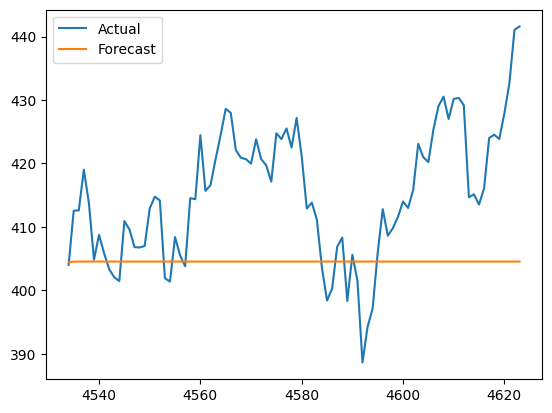

In [69]:
# Convert RangeIndex objects to Series
test_data_dates = pd.Series(test_data.index)
forecast_dates = pd.Series(forecast_dates)

forecast_dates = pd.concat([test_data_dates, forecast_dates])

plt.plot(test_data["Close"], label='Actual')
plt.plot(forecast, label='Forecast')

plt.legend()
plt.show()

### Random Forest Regressor with XGBoost 

In [70]:
data

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,S_3,S_9,...,RSI,Bollinger_Mid,Bollinger_Upper,Bollinger_Lower,Volume_Rolling_Mean,Volume_Change,Overall_Mean,Overall_Min,Overall_Max,Target
0,2006-01-31 00:00:00-05:00,19.679359,20.010756,19.651156,19.848583,94841300,0.0,0.0,19.728718,19.029883,...,65.753580,19.034545,19.762916,18.306173,92388520.0,-0.088057,97.452772,11.263444,442.570007,19.771023
1,2006-02-01 00:00:00-05:00,19.714613,19.792175,19.573594,19.771023,68448800,0.0,0.0,19.787475,19.109795,...,60.807054,19.076851,19.873499,18.280204,94263860.0,-0.278281,97.452772,11.263444,442.570007,19.517185
2,2006-02-02 00:00:00-05:00,19.721664,19.735766,19.425521,19.517185,55073400,0.0,0.0,19.712264,19.209293,...,57.336928,19.101882,19.921677,18.282087,91376680.0,-0.195407,97.452772,11.263444,442.570007,19.418478
3,2006-02-03 00:00:00-05:00,19.376171,19.531294,19.277457,19.418478,75022700,0.0,0.0,19.568895,19.302523,...,54.642099,19.121273,19.952245,18.290300,79477080.0,0.362231,97.452772,11.263444,442.570007,19.157589
4,2006-02-06 00:00:00-05:00,19.397323,19.418477,19.101181,19.157589,60170500,0.0,0.0,19.364417,19.372250,...,52.284319,19.130439,19.958623,18.302255,70711340.0,-0.197969,97.452772,11.263444,442.570007,18.995409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4619,2024-06-07 00:00:00-04:00,426.200012,426.279999,423.000000,423.850006,13621700,0.0,0.0,424.126668,421.251116,...,53.910632,422.018918,434.639662,409.398174,15460920.0,-0.083411,97.452772,11.263444,442.570007,427.869995
4620,2024-06-10 00:00:00-04:00,424.700012,428.079987,423.890015,427.869995,14003000,0.0,0.0,425.413330,420.978892,...,52.784505,422.712755,434.997026,410.428483,14764580.0,0.027992,97.452772,11.263444,442.570007,432.679993
4621,2024-06-11 00:00:00-04:00,425.480011,432.820007,425.250000,432.679993,14551100,0.0,0.0,428.133331,421.368890,...,53.910602,423.698000,435.854008,411.541992,14805020.0,0.039142,97.452772,11.263444,442.570007,441.059998
4622,2024-06-12 00:00:00-04:00,435.320007,443.399994,433.250000,441.059998,22366200,0.0,0.0,433.869995,424.301110,...,59.861540,424.960500,438.795929,411.125070,15880660.0,0.537080,97.452772,11.263444,442.570007,441.579987


In [78]:
rfr_X = data.drop(["Close","Date"],axis = 1)
rfr_y = data["Close"]
X_train, X_test, y_train, y_test = train_test_split(rfr_X,rfr_y,test_size = 0.3,random_state = 101,shuffle = False)

In [79]:
rfr = RandomForestRegressor()
rfr.fit(X_train,y_train)
rfr

RandomForestRegressor()

In [80]:
forecast_preds = rfr.predict(X_test)
forecast_preds

array([100.90947243,  99.92412346, 102.62541191, ..., 108.44333252,
       108.40998283, 108.45925377])

In [ ]:
plt.plot(data["Date"], data["Close"], label='Historical')

plt.plot(data["Date"][-len(forecast_preds):], forecast_preds, label='Forecast')

plt.legend()
plt.show()